# **Population-Level Comparison of Air Quality and Cognitive Performance (2011-2014)**

### CS 210: Data Management for Data Science

**Student:** Hemadharshinii Sendhilvel\
**NetID:** hs1244

--- 

## **Introduction**

This notebook extends the individual-level analysis of cognitive performance to a broader, population-level perspective.

While the previous analysis focused on predicting cognitive performance (DSST scores) using individual demographic and behavioral factors, this notebook examines whether aggregate trends in cognitive performance align with changes in environmental conditions, specifically air quality. 

We compare: 
- NHANES cognitive performance trends (DSST scores) across two survey cycles:
  - 2011-2012
  - 2013-2014
- National-level Air Quality Index (AQI) trends over the same period

### **Research Question**
> Do population-level changes in air quality correspond with changes in average cognitive performance across NHANES cycles?

This analysis is descriptive and exploratory, not causal or predictive.

---

## **Imports & Setup**

In [1]:
# data handling
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style = "whitegrid")

---

## **Data Sources**

This analysis uses:

### NHANES Cognitive Data
We use Digit Symbol Substitution Test (DSST) scores from:
- 2011-2012 cycle (`CFQ_G`)
- 2013-2014 cycle (`CFQ_H`)

DSST (scores range from 0-105) measures processing speed, attention, and executive function. 

### EPA Air Quality Data
We use daily Air Quality Index (AQI) data from the Environmental Protection Agency (EPA):
- Aggregated from county-level daily measurements
- Converted to annual national averages (lower AQI indicates better air quality)
- Covers years: 2011-2014
  
In this analysis, AQI is used as a population-level proxy for environmental exposure.

Note: This analysis uses **aggregate summaries only** due to the lack of consistent geographic identifiers in NHANES public-use data.

---

## **NHANES Cognitive Data Processing**

In [2]:
def clean_dsst(file_path, cycle_name):
    """
    load and clean NHANES cognitive data (DSST scores)

    - load dataset
    - keep only relevant columns
    - remove missing or invalid values
    - restrict to valid DSST score range (0-105)
    - add survey cycle label
    """

    df = pd.read_sas(file_path)
    
    # keep only relevant variables
    df = df[["SEQN", "CFDDS"]]
    
    # rename columns for clarity
    df = df.rename(columns = {
        "SEQN": "id",
        "CFDDS": "dsst_score"
    })
    
    # handle missing values
    df = df.dropna(subset = ["dsst_score"])

    # ensure valid score range
    df = df[(df["dsst_score"] >= 0) & (df["dsst_score"] <= 105)]

    # label cycle
    df["cycle"] = cycle_name

    return df

### **Load NHANES Cycles**

In [3]:
# clean both cqi nhanes datasets

cfq_11_12 = clean_dsst(
    "../data/raw/nhanes/CFQ_G.xpt",
    "2011-2012"
)

cfq_13_14 = clean_dsst(
    "../data/raw/nhanes/CFQ_H.xpt",
    "2013-2014"
)

# combine cycles
cfq_all = pd.concat([cfq_11_12, cfq_13_14], ignore_index = True)

# check
cfq_all.head()

,id,dsst_score,cycle
0,62174.0,33.0,2011-2012
1,62178.0,38.0,2011-2012
2,62191.0,26.0,2011-2012
3,62215.0,47.0,2011-2012
4,62217.0,25.0,2011-2012


---

## **EPA Air Quality Data Processing**

In [4]:
def clean_aqi(file_path):
    """
    load and clean EPA AQI daily data

    - load csv
    - convert date column
    - extract year
    - standardize AQI column name
    """

    # read file
    df = pd.read_csv(file_path)

    # extract date & year
    df["Date"] = pd.to_datetime(df["Date"])
    df["year"] = df["Date"].dt.year

    # rename for clarity
    df = df.rename(columns = {"AQI": "aqi"})

    return df

### **Load AQI Data**

In [6]:
# clean aqi datasets

aqi_2011 = clean_aqi("../data/raw/epa/daily_aqi_by_county_2011.csv")
aqi_2012 = clean_aqi("../data/raw/epa/daily_aqi_by_county_2012.csv")
aqi_2013 = clean_aqi("../data/raw/epa/daily_aqi_by_county_2013.csv")
aqi_2014 = clean_aqi("../data/raw/epa/daily_aqi_by_county_2014.csv")

# combine all years
aqi_all = pd.concat([aqi_2011, aqi_2012, aqi_2013, aqi_2014], ignore_index = True)

# check
aqi_all.head()

,State Name,county Name,State Code,County Code,Date,aqi,Category,Defining Parameter,Defining Site,Number of Sites Reporting,year
0,Alabama,Baldwin,1,3,2011-01-03,34,Good,PM2.5,01-003-0010,1,2011
1,Alabama,Baldwin,1,3,2011-01-06,53,Moderate,PM2.5,01-003-0010,1,2011
2,Alabama,Baldwin,1,3,2011-01-09,33,Good,PM2.5,01-003-0010,1,2011
3,Alabama,Baldwin,1,3,2011-01-12,34,Good,PM2.5,01-003-0010,1,2011
4,Alabama,Baldwin,1,3,2011-01-15,64,Moderate,PM2.5,01-003-0010,1,2011


---

## **Aggregation to Population Level**

### **NHANES DSST: Mean Cognitive Performance by Cycle**

In [11]:
# aggregate
cfq_summary = (
    cfq_all.groupby("cycle")
    .agg(mean_dsst = ("dsst_score", "mean"))
    .reset_index()
)

# check
cfq_summary

,cycle,mean_dsst
0,2011-2012,44.912799
1,2013-2014,45.951005


### **EPA AQI: Mean Air Quality by Year**

In [12]:
# aggregate
aqi_yearly = (
    aqi_all.groupby("year")
    .agg(avg_aqi = ("aqi", "mean"))
    .reset_index()
)

# check
aqi_yearly

,year,avg_aqi
0,2011,46.855448
1,2012,47.205372
2,2013,44.177343
3,2014,43.596317


### **Align AQI with NHANES Cycles**

We map annual AQI to NHANES survey cycles for comparison.

In [15]:
# map AQI to NHANES cycles
aqi_cycle_summary = pd.DataFrame({
    "cycle": ["2011-2012", "2013-2014"],
    "mean_aqi": [
        aqi_yearly[aqi_yearly["year"].isin([2011, 2012])]["avg_aqi"].mean(),
        aqi_yearly[aqi_yearly["year"].isin([2013, 2014])]["avg_aqi"].mean()
    ]
})

# check
aqi_cycle_summary

,cycle,mean_aqi
0,2011-2012,47.03041
1,2013-2014,43.88683


### **Final Merged Dataset**

In [16]:
final = cfq_summary.merge(aqi_cycle_summary, on = "cycle")

# check merged dataset
final

,cycle,mean_dsst,mean_aqi
0,2011-2012,44.912799,47.03041
1,2013-2014,45.951005,43.88683


---

## **Visualization: Cognition vs Air Quality**

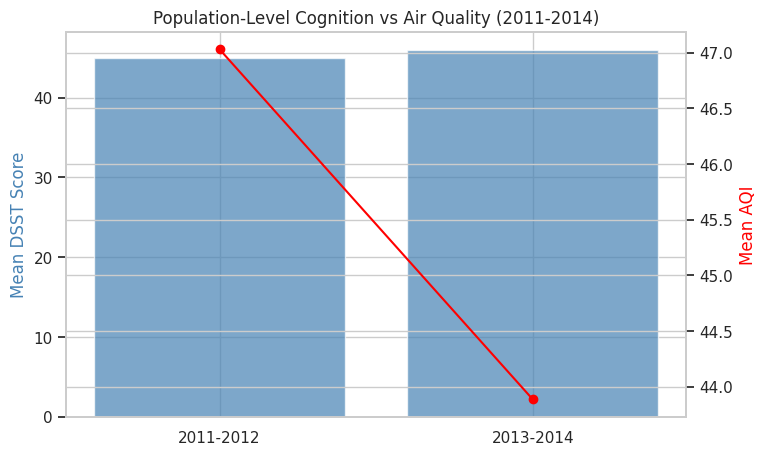

In [17]:
fig, ax1 = plt.subplots(figsize = (8, 5))

# DSST scores
ax1.bar(final["cycle"], final["mean_dsst"], color = "steelblue", alpha = 0.7)
ax1.set_ylabel("Mean DSST Score", color = "steelblue")

# AQI trend
ax2 = ax1.twinx()
ax2.plot(final["cycle"], final["mean_aqi"], color = "red", marker = "o")
ax2.set_ylabel("Mean AQI", color = "red")

plt.title("Population-Level Cognition vs Air Quality (2011-2014)")
plt.show()

## **Interpretation of Results**

Across the two NHANES cycles, mean DSST scores show a slight increase from 2011-2012 to 2013-2014, while average AQI decreases over the same period.

This pattern suggests a possible inverse pattern, where improved air quality aligns with slightly higher average cognitive scores.

However, this result is **purely observational** and does not imply causation. The observed differences in both DSST scores and AQI are relatively small and may reflect expected sampling variation across independent survey cycles:
- Differences in sample composition across cycles
- Changes in demographic distributions (age, education)
- Uncontrolled socioeconomic or health factors
- Aggregation effects in both NHANES and AQI data

### **Limitations**
- Only two NHANES cycles are compared, limiting trend interpretation
- NHANES samples are cross-sectional, not longitudinal
- AQI is nationally aggregated, masking regional variation
- No control for confounding variables at the population level
- Differences between cycles may reflect sampling variations rather than true temporal change

---

### **Summary**
This analysis provides a **high-level environmental context** for cognitive performance trends.\
While the data show a directional pattern between improving air quality and slightly higher DSST scores, the evidence is not sufficient to support causal conclusions.

These findings motivate further investigation using geographically aligned and individual-level environmental exposure data.

---